# Data Wrangling

In [2]:
import numpy as np
import pandas as pd

## Hierarchical Indexing

### Indexing with a DataFrame’s columns

In [5]:
# misal kita punya suatu data
frame1 = pd.DataFrame({"a": range(7), "b": range(7, 0, -1),
                    "c": ["one", "one", "one", "two", "two",
                     "two", "two"],"d": [0, 1, 2, 0, 1, 2, 3]})
print(frame1)

   a  b    c  d
0  0  7  one  0
1  1  6  one  1
2  2  5  one  2
3  3  4  two  0
4  4  3  two  1
5  5  2  two  2
6  6  1  two  3


In [7]:
# kita bisa mengubah data tersebut menjadi data dengan multi index dari kolomnya
# cara pertama adalah dengan menggunakan set_index
# set_index akan membuat dataframe baru dengan memakai satu atau lebih kolom sebagai index
# misa df baru ingin index kolom c dan d
frame2= frame1.set_index(['c', 'd'])
print(f"datasets dengan multi index dari kolom c dan d:\n{frame2}")
# secara default, set_index akan menghapus kolom yang dijadikan index dari dataframe baru
# bila ingin kolom tersebut tetap ada, bisa menggunakan parameter drop=False
frame3 = frame1.set_index(['c', 'd'], drop=False)
print(f"datasets dengan multi index dari kolom c dan d, tetapi kolom c dan d tetap ada:\n{frame3}")

datasets dengan multi index dari kolom c dan d:
       a  b
c   d      
one 0  0  7
    1  1  6
    2  2  5
two 0  3  4
    1  4  3
    2  5  2
    3  6  1
datasets dengan multi index dari kolom c dan d, tetapi kolom c dan d tetap ada:
       a  b    c  d
c   d              
one 0  0  7  one  0
    1  1  6  one  1
    2  2  5  one  2
two 0  3  4  two  0
    1  4  3  two  1
    2  5  2  two  2
    3  6  1  two  3


In [8]:
# bila ingin index menjadi kolom kembali, bisa menggunakan reset_index
frame4 = frame2.reset_index()
print(f"datasets dengan multi index dari kolom c dan d, tetapi kolom c dan d tetap ada:\n{frame4}")

datasets dengan multi index dari kolom c dan d, tetapi kolom c dan d tetap ada:
     c  d  a  b
0  one  0  0  7
1  one  1  1  6
2  one  2  2  5
3  two  0  3  4
4  two  1  4  3
5  two  2  5  2
6  two  3  6  1


## Combining and Merging Datasets

### Database-Style DataFrame Joins
#### terkadang kita perlu menggabungkan 2 dataset yang berbeda berdasarkan kolom keys

In [9]:
# misal kita punya 2 dataset yang berbeda, tetapi memiliki kolom yang sama
# data pertama memiliki kolom key dan data1, sedangkan data kedua memiliki kolom key dan data2
# jadi kita bisa menggabungkan kedua dataset tersebut berdasarkan kolom key
df1 = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'a', 'b'],
                    'data1':pd.Series(range(7), dtype="int64")})
df2 = pd.DataFrame({'key': ['a', 'b', 'd'],
                    'data2': pd.Series(range(3), dtype="int64")})
print(f"dataset pertama:\n{df1}")
print(f"dataset kedua:\n{df2}")

dataset pertama:
  key  data1
0   b      0
1   b      1
2   a      2
3   c      3
4   a      4
5   a      5
6   b      6
dataset kedua:
  key  data2
0   a      0
1   b      1
2   d      2


In [10]:
# fungsi yang dgunakan adalah merge, yang mirip join pada SQL
# penggabungan disini jenisnya banyak ke satu, karena df1 memiliki 7 baris sedangkan df2 hanya 3 baris
# secara default, merge akan menggabungkan kedua dataset berdasarkan kolom yang sama, yaitu key
# bentuk fungsinya adalah pd.merge(left, right, how='', on=None, left_on=None, right_on=None)
pd.merge(df1, df2)
# hasilnya adalah dataset baru yang memiliki kolom key, data1, dan data2

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [13]:
# sebaiknya kita menspesifikasikan kolom yang dijadikan key, karena bila tidak, maka merge akan menggabungkan berdasarkan semua kolom yang sama
merge1 =pd.merge(df1, df2, on='key')
print(f"hasil merge dengan spesifikasi kolom key:\n{merge1}")

# secara deafult, nilai how adalah inner, yang artinya hanya akan menggabungkan baris yang memiliki key yang sama pada kedua dataset
# bila ingin menggabungkan semua baris dari kedua dataset, bisa menggunakan how='outer'
merge2 = pd.merge(df1, df2, how='outer', on='key')
print(f"hasil merge dengan spesifikasi kolom key dan how='outer':\n{merge2}")

hasil merge dengan spesifikasi kolom key:
  key  data1  data2
0   b      0      1
1   b      1      1
2   a      2      0
3   a      4      0
4   a      5      0
5   b      6      1
hasil merge dengan spesifikasi kolom key dan how='outer':
  key  data1  data2
0   a    2.0    0.0
1   a    4.0    0.0
2   a    5.0    0.0
3   b    0.0    1.0
4   b    1.0    1.0
5   b    6.0    1.0
6   c    3.0    NaN
7   d    NaN    2.0


#### berikut arugumen lengkap untuk How
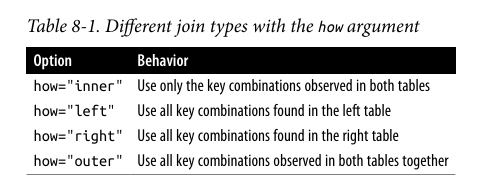

In [14]:
# bila kolomnya memiliki nama yang berbeda, kita bisa menentukan posisi output kolomnya dengan left_on dan right_on
df3 = pd.DataFrame({'lkey': ['b', 'b', 'a', 'c', 'a', 'a', 'b'],
                    'data1':pd.Series(range(7), dtype="int64")})
df4 = pd.DataFrame({'rkey': ['a', 'b', 'd'],
                    'data2': pd.Series(range(3), dtype="int64")})
pd.merge(df3, df4, left_on='lkey', right_on='rkey')

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,a,2,a,0
3,a,4,a,0
4,a,5,a,0
5,b,6,b,1


In [15]:
pd.merge(df3, df4, how='outer', left_on='lkey', right_on='rkey')

,lkey,data1,rkey,data2
0,a,2.0,a,0.0
1,a,4.0,a,0.0
2,a,5.0,a,0.0
3,b,0.0,b,1.0
4,b,1.0,b,1.0
5,b,6.0,b,1.0
6,c,3.0,NaN,NaN
7,NaN,NaN,d,2.0


#### bila kita dari banyak ke banyak(many-to-many) menghasikan perkalian Cartesian, yang artinya semua kombinasi dari kedua dataset akan digabungkan

In [16]:
# misal kita punya 2 dataset yang berbeda, tetapi memiliki kolom yang sama
df1 = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "b"],
                    "data1": pd.Series(range(6), dtype="Int64")})
df2 = pd.DataFrame({"key": ["a", "b", "a", "b", "d"],
                    "data2": pd.Series(range(5), dtype="Int64")})
print(f"dataset pertama:\n{df1}")
print(f"dataset kedua:\n{df2}")

dataset pertama:
  key  data1
0   b      0
1   b      1
2   a      2
3   c      3
4   a      4
5   b      5
dataset kedua:
  key  data2
0   a      0
1   b      1
2   a      2
3   b      3
4   d      4


In [17]:
# bila kita gunakan merge, maka key b menjadi 6
# itu merupakan hasil perkalian 3 baris dari df1 dengan 2 baris dari df2, sehingga menghasilkan 6 baris
pd.merge(df1, df2, on="key", how="inner")

,key,data1,data2
0,b,0,1
1,b,0,3
2,b,1,1
3,b,1,3
4,a,2,0
5,a,2,2
6,a,4,0
7,a,4,2
8,b,5,1
9,b,5,3


#### berikut argumen lengkap yang bisa digunakan pada fungsi merge
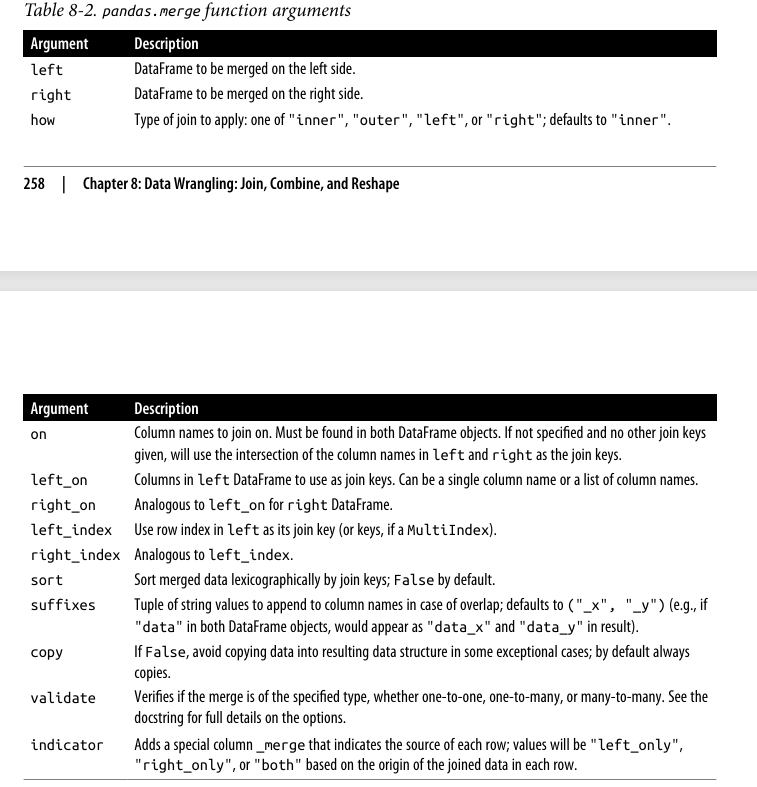

### Concatenating Along an Axis
#### bila merge digunakan untuk menggabungkan dataset berdasarkan kolom keys, maka concat digunakan untuk menggabungkan dataset berdasarkan indexnya(barisnya)

In [18]:
# misal kita punya 3 data series tanpa index yang sama
s1 = pd.Series([0, 1], index=["a", "b"], dtype="Int64")
s2 = pd.Series([2, 3, 4], index=["c", "d", "e"], dtype="Int64")
s3 = pd.Series([5, 6], index=["f", "g"], dtype="Int64")
print(f"data series pertama:\n{s1}")
print(f"data series kedua:\n{s2}")
print(f"data series ketiga:\n{s3}")

data series pertama:
a    0
b    1
dtype: Int64
data series kedua:
c    2
d    3
e    4
dtype: Int64
data series ketiga:
f    5
g    6
dtype: Int64


In [19]:
# dengan pandas.concat, list ini akan digabungkan menjadi series tunggal, dengan memasukakn baris dari s1, s2, dan s3 ke dalam series baru
pd.concat([s1, s2, s3])

a    0
b    1
c    2
d    3
e    4
f    5
g    6
dtype: Int64

In [20]:
# kita juga bisa mengganti axisnya, 
# sehingga akan menjadi dataframe dengan baris gabungan index dari ketiga series dan 3 kolom sesuai jumlah series
pd.concat([s1, s2, s3], axis='columns')

,0,1,2
a,0,<NA>,<NA>
b,1,<NA>,<NA>
c,<NA>,2,<NA>
d,<NA>,3,<NA>
e,<NA>,4,<NA>
f,<NA>,<NA>,5
g,<NA>,<NA>,6


#### berikut argumen lengkap fungsi concat
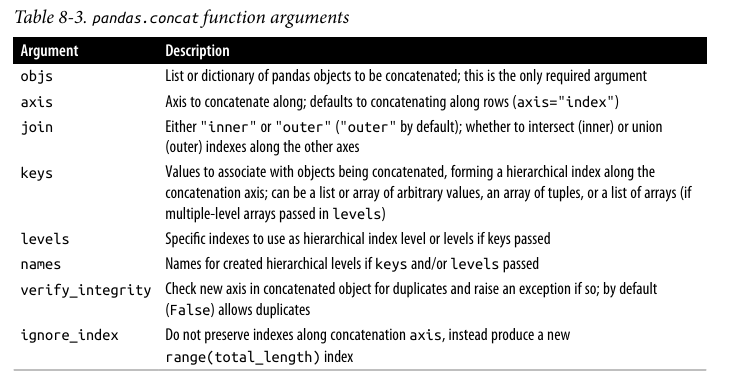

## Reshaping and Pivoting

### Pivoting “Long” to “Wide” Format

In [42]:
# bila kita punya data dengan baris yang banyak, kita bisa menggunakan pivot untuk mengubah data menjadi lebih ringkas
# baris yang pnajng bisa diubah menjadi kolom
# misal kita punya data berikut
data = pd.read_csv('examples/macrodata.csv')
data = data.loc[:, ["year", "quarter", "realgdp", "infl", "unemp"]]
data.head()

,year,quarter,realgdp,infl,unemp
0,1959.0,1.0,2710.349,0.00,5.8
1,1959.0,2.0,2778.801,2.34,5.1
2,1959.0,3.0,2775.488,2.74,5.3
3,1959.0,4.0,2785.204,0.27,5.6
4,1960.0,1.0,2847.699,2.31,5.2


In [43]:
# kita ingin index dalam bentuk waktu, sehingga kita bisa mengubah kolom year dan quarter menjadi index
# Ambil year dan quarter
years = data.pop("year")
quarters = data.pop("quarter")

# Buat PeriodIndex dengan format string YYYYQX
periods = pd.PeriodIndex(
    [f"{int(y)}Q{int(q)}" for y, q in zip(years, quarters)],
    freq='Q-DEC',        # Q-DEC = quarter ending in December
    name="date"
)

data.index = periods.to_timestamp("D")
data.head()

,realgdp,infl,unemp
date,,,
1959-01-01,2710.349,0.00,5.8
1959-04-01,2778.801,2.34,5.1
1959-07-01,2775.488,2.74,5.3
1959-10-01,2785.204,0.27,5.6
1960-01-01,2847.699,2.31,5.2


In [45]:
data = data.reindex(columns=["realgdp", "infl", "unemp"])
data.columns.name = "item"
data.head()

item,realgdp,infl,unemp
date,,,
1959-01-01,2710.349,0.00,5.8
1959-04-01,2778.801,2.34,5.1
1959-07-01,2775.488,2.74,5.3
1959-10-01,2785.204,0.27,5.6
1960-01-01,2847.699,2.31,5.2


In [ ]:
long_data = (data.stack()
             .reset_index()
             .rename(columns={0: "value"}))
long_data[:10] # akan menghasiklan data long form dengan kolom date, item, dan value

,date,item,value
0,1959-01-01,realgdp,2710.349
1,1959-01-01,infl,0.000
2,1959-01-01,unemp,5.800
3,1959-04-01,realgdp,2778.801
4,1959-04-01,infl,2.340
5,1959-04-01,unemp,5.100
6,1959-07-01,realgdp,2775.488
7,1959-07-01,infl,2.740
8,1959-07-01,unemp,5.300
9,1959-10-01,realgdp,2785.204


In [47]:
# dengan pivot kita bisa mengubah data long menjadi data wide(baris menjadi kolom)
pivoted = long_data.pivot(index='date', columns='item', values='value')
pivoted.head()

item,infl,realgdp,unemp
date,,,
1959-01-01,0.00,2710.349,5.8
1959-04-01,2.34,2778.801,5.1
1959-07-01,2.74,2775.488,5.3
1959-10-01,0.27,2785.204,5.6
1960-01-01,2.31,2847.699,5.2


In [48]:
# misa kolom valuenya ada 2
long_data["value2"] = np.random.standard_normal(len(long_data))
long_data[:10] # akan menghasiklan data long form dengan kolom date, item, value, dan value2

,date,item,value,value2
0,1959-01-01,realgdp,2710.349,0.182589
1,1959-01-01,infl,0.000,-0.730206
2,1959-01-01,unemp,5.800,0.326249
3,1959-04-01,realgdp,2778.801,0.867160
4,1959-04-01,infl,2.340,-0.624982
5,1959-04-01,unemp,5.100,-1.277189
6,1959-07-01,realgdp,2775.488,-2.028574
7,1959-07-01,infl,2.740,-1.269439
8,1959-07-01,unemp,5.300,0.566135
9,1959-10-01,realgdp,2785.204,0.351583


In [50]:
# dengan membuang argumen values, maka pivot akan mengembalikan dataframe dengan multi index kolom
pivoted = long_data.pivot(index='date', columns='item')
pivoted.head()

value                    value2                    
item        infl   realgdp unemp      infl   realgdp     unemp
date                                                          
1959-01-01  0.00  2710.349   5.8 -0.730206  0.182589  0.326249
1959-04-01  2.34  2778.801   5.1 -0.624982  0.867160 -1.277189
1959-07-01  2.74  2775.488   5.3 -1.269439 -2.028574  0.566135
1959-10-01  0.27  2785.204   5.6  1.086330  0.351583 -1.465206
1960-01-01  2.31  2847.699   5.2  1.300882  0.263999  1.268463

In [51]:
pivoted["value"].head() # akan menampilkan data untuk kolom 'value'

item,infl,realgdp,unemp
date,,,
1959-01-01,0.00,2710.349,5.8
1959-04-01,2.34,2778.801,5.1
1959-07-01,2.74,2775.488,5.3
1959-10-01,0.27,2785.204,5.6
1960-01-01,2.31,2847.699,5.2


### Pivoting “Wide” to “Long” Format

In [52]:
# kita memiliki operasi inverse dari pivot, yaitu melt, yang akan mengubah data wide menjadi data long (kolom menjadi baris)
# misal kita punya data berikut
df = pd.DataFrame({"key": ["foo", "bar", "baz"],
                   "A": [1, 2, 3],
                   "B": [4, 5, 6],
                   "C": [7, 8, 9]})
df

,key,A,B,C
0,foo,1,4,7
1,bar,2,5,8
2,baz,3,6,9


In [ ]:
# misa kolum key adalah identifier, sedangkan kolom A, B, dan C adalah value
melted = pd.melt(df, id_vars="key")
print(f"hasil melt:\n{melted}")

hasil melt:
   key variable  value
0  foo        A      1
1  bar        A      2
2  baz        A      3
3  foo        B      4
4  bar        B      5
5  baz        B      6
6  foo        C      7
7  bar        C      8
8  baz        C      9


In [54]:
# kita juga bisa menspesifikasikan kolom mana yang dijadikan identifier, dan kolom mana yang dijadikan value
melted2 = pd.melt(df, id_vars=["key"], value_vars=["A", "B"])
print(f"hasil melt dengan spesifikasi kolom A dan B sebagai value:\n{melted2}")

hasil melt dengan spesifikasi kolom A dan B sebagai value:
   key variable  value
0  foo        A      1
1  bar        A      2
2  baz        A      3
3  foo        B      4
4  bar        B      5
5  baz        B      6


In [55]:
# kita juga tidak menspesifikkan kolom identifier
melted3 = pd.melt(df, value_vars=["A", "B", "C"])
print(f"hasil melt tanpa spesifikasi kolom identifier:\n{melted3}")

hasil melt tanpa spesifikasi kolom identifier:
  variable  value
0        A      1
1        A      2
2        A      3
3        B      4
4        B      5
5        B      6
6        C      7
7        C      8
8        C      9


In [56]:
# kita juga bisa menggantikan nama kolom identifier dan value dengan parameter var_name dan value_name
melted4 = pd.melt(df, id_vars=["key"], value_vars=["A", "B"], var_name="variable", value_name="value")
print(f"hasil melt dengan mengganti nama kolom identifier dan value:\n{melted4}")

hasil melt dengan mengganti nama kolom identifier dan value:
   key variable  value
0  foo        A      1
1  bar        A      2
2  baz        A      3
3  foo        B      4
4  bar        B      5
5  baz        B      6
